In [1]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


...


[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

# Define the file path
file_path = 'D:/DSGP project/DSGP/datasets/raw/Crop_and_fertilizer_dataset.csv'

# Load the dataset
df = pd.read_csv(file_path)

# Display dataset information
print("First few rows of the dataset:")
print(df.head())

print("\nDataset information:")
print(df.info())


First few rows of the dataset:
  District_Name Soil_color  Nitrogen  Phosphorus  Potassium   pH  Rainfall  \
0      Kolhapur      Black        75          50        100  6.5      1000   
1      Kolhapur      Black        80          50        100  6.5      1000   
2      Kolhapur      Black        85          50        100  6.5      1000   
3      Kolhapur      Black        90          50        100  6.5      1000   
4      Kolhapur      Black        95          50        100  6.5      1000   

   Temperature       Crop Fertilizer                          Link  
0           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  
1           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  
2           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  
3           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  
4           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4513 entries, 

In [3]:
# Filter for rice data
rice_df = df[df['Crop'].str.lower() == 'rice']

# Drop unnecessary columns
rice_df = rice_df.drop(columns=['District_Name', 'Link', 'Crop','Soil_color'], errors='ignore')

# Display the first few rows of the rice dataset
print("First few rows of the rice dataset:")

print(rice_df.head())
print(rice_df.shape)

First few rows of the rice dataset:
     Nitrogen  Phosphorus  Potassium   pH  Rainfall  Temperature Fertilizer
624        20          15         20  5.5       700           25       Urea
625        25          15         20  5.5       700           25       Urea
626        30          15         20  5.5       700           25       Urea
627        20          20         25  6.0       800           30       Urea
628        25          20         25  6.0       800           30       Urea
(309, 7)


In [4]:
# Check for missing values
missing_values = rice_df.isnull().sum()

# Check for duplicates
duplicates = rice_df.duplicated().sum()

missing_values, duplicates

(Nitrogen       0
 Phosphorus     0
 Potassium      0
 pH             0
 Rainfall       0
 Temperature    0
 Fertilizer     0
 dtype: int64,
 np.int64(0))

In [5]:
from sklearn.preprocessing import LabelEncoder
# Filter for Rice data
rice_df = df[df['Crop'].str.lower() == 'rice'].drop(columns=['District_Name', 'Link', 'Crop']).reset_index(drop=True)

# Label Encoding for Fertilizer
label_encoder = LabelEncoder()
rice_df['Fertilizer_Encoded'] = label_encoder.fit_transform(rice_df['Fertilizer'])

# Save the mapping for future reference
fertilizer_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

# Drop original columns
rice_df = rice_df.drop(columns=[ 'Fertilizer'])

# Display encoded dataset
print("Encoded Rice Dataset:")
print(rice_df.head())

Encoded Rice Dataset:
     Soil_color  Nitrogen  Phosphorus  Potassium   pH  Rainfall  Temperature  \
0  Medium Brown        20          15         20  5.5       700           25   
1  Medium Brown        25          15         20  5.5       700           25   
2  Medium Brown        30          15         20  5.5       700           25   
3  Medium Brown        20          20         25  6.0       800           30   
4  Medium Brown        25          20         25  6.0       800           30   

   Fertilizer_Encoded  
0                   1  
1                   1  
2                   1  
3                   1  
4                   1  


In [6]:
# Function to detect and remove outliers using the IQR method
def remove_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Define outlier bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Remove outliers
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

    return df

# Apply the function to relevant numerical columns
numerical_columns = ['Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature']
rice_df_cleaned = remove_outliers_iqr(rice_df, numerical_columns)

print(f"Number of records before outlier removal: {len(rice_df)}")
print(f"Number of records after outlier removal: {len(rice_df_cleaned)}")

# Display the cleaned dataset
print("\nCleaned Rice Dataset:")
print(rice_df_cleaned.head())


Number of records before outlier removal: 309
Number of records after outlier removal: 270

Cleaned Rice Dataset:
   Soil_color  Nitrogen  Phosphorus  Potassium   pH  Rainfall  Temperature  \
39        Red        80          40         40  6.0      1000           25   
40        Red        85          40         40  6.0      1000           25   
41        Red        90          40         40  6.0      1000           25   
42        Red        95          40         40  6.0      1000           25   
43        Red       100          40         40  6.0      1000           25   

    Fertilizer_Encoded  
39                   1  
40                   1  
41                   1  
42                   1  
43                   1  


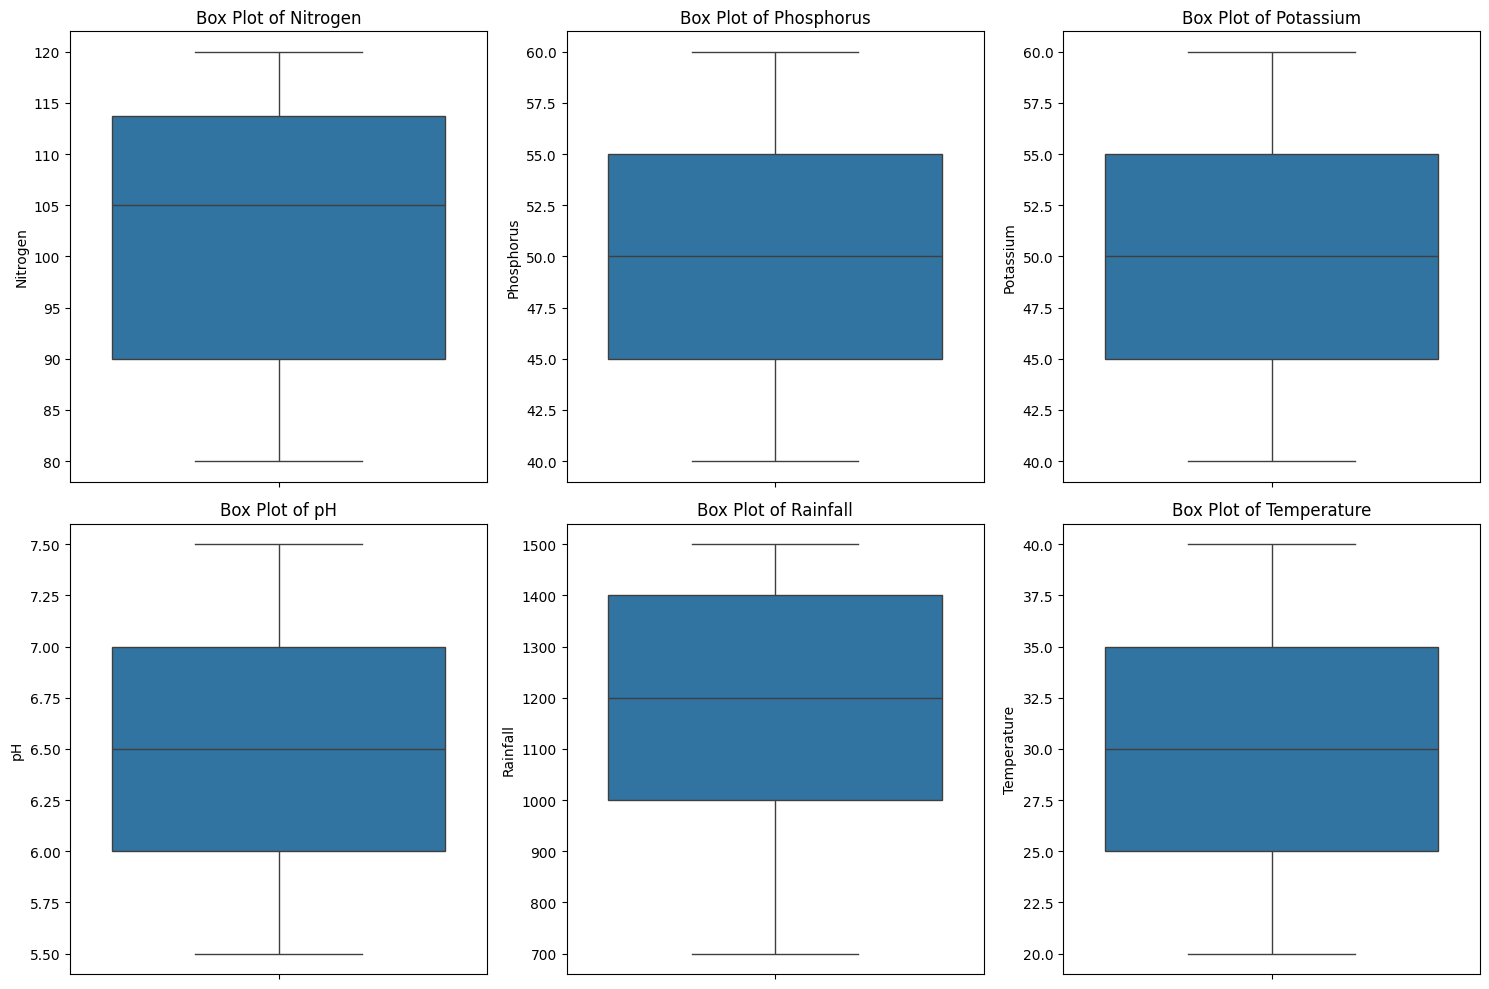

In [7]:
# box plots for each numerical column after outlier removal

import matplotlib.pyplot as plt
import seaborn as sns

# Create box plots for each numerical column in the cleaned dataset
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_columns):
    plt.subplot(2, 3, i + 1)  # Adjust subplot layout as needed
    sns.boxplot(y=rice_df_cleaned[col])
    plt.title(f'Box Plot of {col}')

plt.tight_layout()
plt.show()


In [8]:
from sklearn.preprocessing import StandardScaler

# Scale numerical features
scaler = StandardScaler()
numerical_features = ['Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature']
rice_df[numerical_features] = scaler.fit_transform(rice_df[numerical_features])


In [9]:
# Save the preprocessed dataset to a new CSV file
file_path_cleaned = 'D:/DSGP project/DSGP/datasets/processed/rice_preprocessed_data.csv'  
rice_df_cleaned.to_csv(file_path_cleaned, index=False)


In [10]:
%pip install scikit-learn

Training Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        99
           1       1.00      1.00      1.00       148

    accuracy                           1.00       247
   macro avg       1.00      1.00      1.00       247
weighted avg       1.00      1.00      1.00       247



In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# Features and target
X = rice_df[numerical_features]
y = rice_df['Fertilizer_Encoded']

# Split data into training and testing sets (keeping 20% for testing later)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Get training accuracy
y_train_pred = rf_model.predict(X_train)
training_accuracy = accuracy_score(y_train, y_train_pred)
print("Training Accuracy:", training_accuracy)

# Print the classification report for the training set
print(classification_report(y_train, y_train_pred))


Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Training Accuracy (Best Model): 1.0
Testing Accuracy (Best Model): 0.9838709677419355
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        25
           1       0.97      1.00      0.99        37

    accuracy                           0.98        62
   macro avg       0.99      0.98      0.98        62
weighted avg       0.98      0.98      0.98        62



In [12]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='accuracy')

# Fit the GridSearchCV object to the training data
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

# Get the best model
best_rf_model = grid_search.best_estimator_

# Evaluate the best model on the training set
y_train_pred = best_rf_model.predict(X_train)
training_accuracy = accuracy_score(y_train, y_train_pred)
print("Training Accuracy (Best Model):", training_accuracy)

# Evaluate the best model on the testing set
y_test_pred = best_rf_model.predict(X_test)
testing_accuracy = accuracy_score(y_test, y_test_pred)
print("Testing Accuracy (Best Model):", testing_accuracy)

# Print the classification report for the testing set
print(classification_report(y_test, y_test_pred))

XGBoost Training Accuracy: 0.9392712550607287
XGBoost Testing Accuracy: 0.9032258064516129
XGBoost Classification Report:
               precision    recall  f1-score   support

50:26:26 NPK       0.95      0.80      0.87        25
        Urea       0.88      0.97      0.92        37

    accuracy                           0.90        62
   macro avg       0.92      0.89      0.90        62
weighted avg       0.91      0.90      0.90        62



c:\Users\dinit\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [08:36:29] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


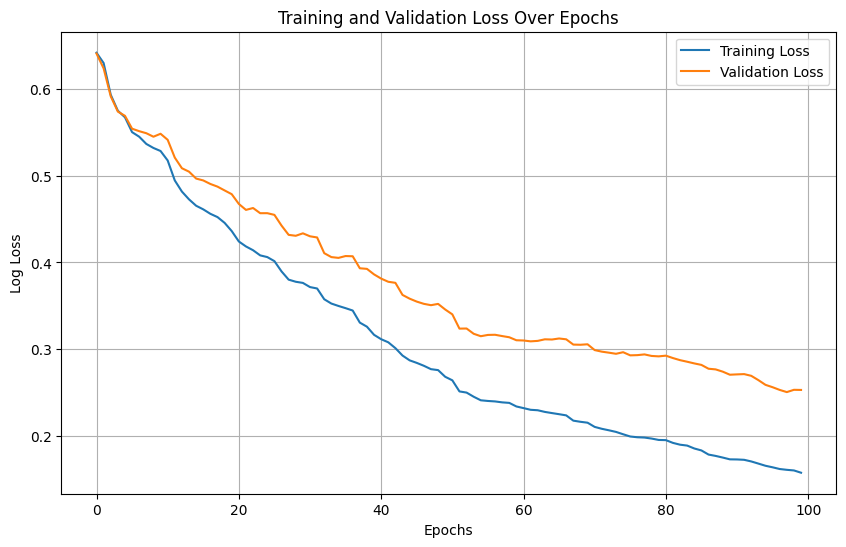

In [14]:
%pip install matplotlib
%pip install seaborn

In [15]:
%pip install xgboost

XGBoost model saved successfully.


In [16]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Optimized XGBoost parameters 
xgb_model = XGBClassifier(
    learning_rate=0.1,
    max_depth=4,
    n_estimators=35,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train the XGBoost model
xgb_model.fit(X_train, y_train)

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

# Accuracy
xgb_training_accuracy = accuracy_score(y_train, y_train_pred_xgb)
xgb_testing_accuracy = accuracy_score(y_test, y_test_pred_xgb)

# Classification report
xgb_classification_report = classification_report(y_test, y_test_pred_xgb, target_names=label_encoder.classes_)

print(f"XGBoost Training Accuracy: {xgb_training_accuracy}")
print(f"XGBoost Testing Accuracy: {xgb_testing_accuracy}")
print("XGBoost Classification Report:\n", xgb_classification_report)



Predicted Fertilizer: Urea


c:\Users\dinit\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:19:39] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


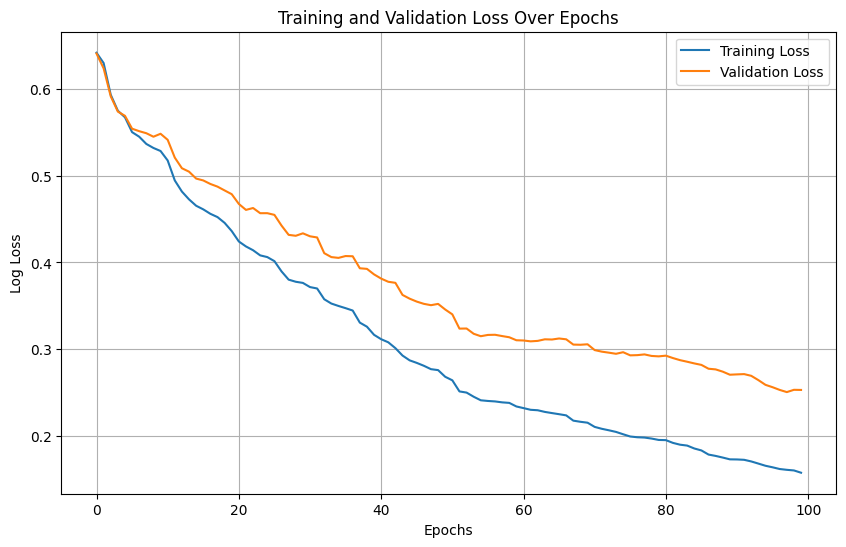

In [23]:
import matplotlib.pyplot as plt

# Train XGBoost with eval_set to track training and validation metrics
eval_set = [(X_train, y_train), (X_test, y_test)]
xgb_model_with_eval = XGBClassifier(
    learning_rate=0.1,
    max_depth=4,
    n_estimators=100,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Fit the model and track evaluation metrics
xgb_model_with_eval.fit(X_train, y_train, eval_set=eval_set, verbose=False)

# Retrieve evaluation results
evals_result = xgb_model_with_eval.evals_result()

# Plotting the training and validation loss over epochs
plt.figure(figsize=(10, 6))
plt.plot(evals_result['validation_0']['logloss'], label='Training Loss')
plt.plot(evals_result['validation_1']['logloss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Log Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()


In [24]:
%pip install joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
# Save the trained XGBoost model

import joblib

joblib.dump(xgb_model, 'D:/DSGP project/DSGP/backend/models/xgb_rice_fertilizer_model.joblib')
print("XGBoost model saved successfully.")




XGBoost model saved successfully.


In [1]:
import joblib
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load the saved model
model_path = 'D:/DSGP project/DSGP/backend/models/xgb_rice_fertilizer_model.joblib'
xgb_model = joblib.load(model_path)

# Define the scaler (make sure it's consistent with training)
scaler = StandardScaler()

# Function to predict fertilizer
def predict_fertilizer(n, p, k, ph, rainfall, temperature):
    # Create a DataFrame for input
    input_data = pd.DataFrame({
        'Nitrogen': [n],
        'Phosphorus': [p],
        'Potassium': [k],
        'pH': [ph],
        'Rainfall': [rainfall],
        'Temperature': [temperature]
    })

    # Scale the input data
    input_scaled = scaler.fit_transform(input_data)  # Use the same scaler as training

    # Make the prediction
    prediction = xgb_model.predict(input_scaled)

    # Decode the label
    fertilizer_mapping = {0: '50:26:26 NPK', 1: 'Urea'}
    predicted_fertilizer = fertilizer_mapping[prediction[0]]

    return predicted_fertilizer

# Command-line input
if __name__ == "__main__":
    n = float(input("Enter Nitrogen (N) value: "))
    p = float(input("Enter Phosphorus (P) value: "))
    k = float(input("Enter Potassium (K) value: "))
    ph = float(input("Enter pH level: "))
    rainfall = float(input("Enter Rainfall (in mm): "))
    temperature = float(input("Enter Temperature (in °C): "))

    result = predict_fertilizer(n, p, k, ph, rainfall, temperature)
    print(f"Predicted Fertilizer: {result}")


Predicted Fertilizer: Urea
